# Phase 1: Data Exploration and Cleaning:

First, we set up the environment with the necessary libraries:

In [299]:
# Libraries for data processing:
import pandas as pd
import numpy as np

# To be able to see all columns from the data frames:
pd.set_option('display.max_columns', None) 

# Data visualization:
import matplotlib.pyplot as plt
import seaborn as sns

# Advanced technology for impuation:
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 

# **1. Initial Data Exploration**

## Loading the csv files

In [300]:
df_flights = pd.read_csv("original-data/customer-flight-activity.csv")
df_customers = pd.read_csv("original-data/customer-loyal-history.csv")

## First look to the dataframes (head,tail, sample, shape, info)

In [301]:
# I define one function for the initial exploration:
def initial_exploration(df,name="dataframe"):
    print(f"The dataframe '{name}' has {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.head(2))
    print("="*150)
    display(df.tail(2))
    print("="*150)
    display(df.sample(2))
    print("="*150)
    print(f"Below all the columns listed with the non-null count and the data type:")
    print("="*150)
    print(df.info())
    print("="*150)


In [302]:
initial_exploration(df_flights, name="df_flights") # Comments at the end of this section

The dataframe 'df_flights' has 405624 rows and 10 columns.


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
333833,773857,2018,8,0,0,0,0,0.0,0,0
96610,743001,2017,6,16,0,16,4368,436.0,0,0


Below all the columns listed with the non-null count and the data type:
<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB
None


In [303]:
initial_exploration(df_customers, name="df_customers") # Comments at the end of this section

The dataframe 'df_customers' has 16737 rows and 16 columns.


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
2618,250280,Canada,British Columbia,Vancouver,V6E 3D9,Male,Bachelor,59647.0,Married,Aurora,8521.74,Standard,2016,12,NaN,NaN
14090,612664,Canada,Quebec,Montreal,H2T 2J6,Female,Master,126642.0,Married,Star,6057.07,Standard,2016,7,NaN,NaN


Below all the columns listed with the non-null count and the data type:
<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float

## Initial identification of null values

In [304]:
df_flights.isnull().sum() # Comments at the end of this section

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [305]:
df_customers.isnull().sum() # Comments at the end of this section

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [306]:
# Let's analize only the columns with nulls and calculate the percentage of nulls on each:
percentage_nulls_customers = (df_customers.isnull().sum() / df_customers.shape[0]) *100 # To calculate % of nulls
df_nulls_customers = pd.DataFrame(percentage_nulls_customers, columns=["%_nulls"]) # To create dataframe
df_nulls_customers = round(df_nulls_customers.sort_values(by="%_nulls", ascending=False),2) # Data frame sorted and values rounded
mask_nulls_customers = df_nulls_customers["%_nulls"] > 0 # mask to filter only the columns with null values
df_nulls_customers = df_nulls_customers[mask_nulls_customers]
df_nulls_customers


,%_nulls
Cancellation Year,87.65
Cancellation Month,87.65
Salary,25.32


## Basic stastics and quick values analysis for each column

### Numerical variables

Use of df.describe() to have a first glance on the centralization measurements (mean and median) and some other important statictical measurements such as standard deviation and the percentiles.

In [307]:
df_flights.describe().T
# we can see that in most of the columns, the mean and the median values are not comparable. 
# This may indicate that the most frequent travellers are affecting the whole dataset values.
# More comments at the end of the section.

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
Year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
Month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
Flights Booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
Flights with Companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
Total Flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
Distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
Points Accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
Points Redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


In [308]:
df_customers.describe().T
# Negative values in salary.
# Probably the customers who flight the most have a higher CLV, which affects clearly the values (the mean and the median differ).
# More comments at the end of the section.

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


### Categorical variables

Use of df.describe (specifying to include only "object or str") to have a look to how many times we have values on each column, together with the number of unique values (this indicate us the categories per each colum).

The term "top" indicate us the mode for each column (the category that holds the number 1 in terms on hoy many times appears on each column), followed by the "freq" which tells us the absolute frequency of the "top".

In [309]:
df_customers.describe(include="str").T
# Canada as only country
# More comments at the end of the section.

,count,unique,top,freq
Country,16737,1,Canada,16737
Province,16737,11,Ontario,5404
City,16737,29,Toronto,3351
Postal Code,16737,55,V6E 3D9,911
Gender,16737,2,Female,8410
Education,16737,5,Bachelor,10475
Marital Status,16737,3,Married,9735
Loyalty Card,16737,3,Star,7637
Enrollment Type,16737,2,Standard,15766


Let's analyse the different unique values for each category:

In [310]:
col_cat_customers = df_customers.select_dtypes(include = "str").columns

for col in col_cat_customers:
    print("=" * 100)
    print(f"We are analizing the categories of the column: {col.upper()}")
    print("=" * 100)
    print(df_customers[col].unique())

We are analizing the categories of the column: COUNTRY
<StringArray>
['Canada']
Length: 1, dtype: str
We are analizing the categories of the column: PROVINCE
<StringArray>
[             'Ontario',              'Alberta',     'British Columbia',
               'Quebec',                'Yukon',        'New Brunswick',
             'Manitoba',          'Nova Scotia',         'Saskatchewan',
         'Newfoundland', 'Prince Edward Island']
Length: 11, dtype: str
We are analizing the categories of the column: CITY
<StringArray>
[       'Toronto',       'Edmonton',      'Vancouver',           'Hull',
     'Whitehorse',        'Trenton',       'Montreal',   'Dawson Creek',
    'Quebec City',    'Fredericton',         'Ottawa',      'Tremblant',
        'Calgary',    'Thunder Bay',       'Whistler',    'Peace River',
       'Winnipeg',        'Sudbury', 'West Vancouver',        'Halifax',
         'London',         'Regina',        'Kelowna',     'St. John's',
       'Victoria',       'Kingsto

### Comments after the first initial data exploration for data cleaning
(deep statistical analysis will be done in Phase 2)

In [311]:
# DF_FLIGHTS: 
    # There are no null values 
    # Column names --> Replace blank spaces with "_" and write all letters in lower case
    # Loyalty number --> We won't do any statistics with this column, therefore no need to have these values as int.
    # Month column (int) --> To change to str (to have months written)


#DF_CUSTOMERS: 
    # We have nulls on: Salary / Cancellation Year / Cancellation Month (although this may be correct)
    # Column names --> Replace blank spaces with "_" and write all letters in lower case
    # Loyalty number: We won't do any statistics with this columns, therefore no need to have these values as int.
    # Country column --> Only value is Canada. To delete the country column for this analysis. 
    # Salary column --> There are negative values. Also nulls.
    # Enrollment Month (int) --> I want to have the months written.
    # Cancellation Year (float): To change to int. Some values are nulls (which may indicate that the customers are still active)
    # Cancellation Month (float): I want to have the months written. Some values are nulls (which may be correct) 

# **2. Data Cleaning**

## Standardizing column names

Good practice: Remove any blank spaces.

In [312]:
# We define a function to allow us standardize the column names:

def standardize_col_names(df):
    # We create a dictionary with keys: old column and values: new column name. 
    # # By using a list comprehension we apply those changes quickly with only one line of code.

    new_cols = {
        col: col.lower().replace(" ", "_") for col in df.columns}
    df.rename(columns=new_cols, inplace=True)
    return df


In [313]:
# FLIGHTS DATAFRAME:
df_flights = standardize_col_names(df_flights)
df_flights.columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed'],
      dtype='str')

In [314]:
# CUSTOMERS DATAFRAME:
df_customers = standardize_col_names(df_customers)
df_customers.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month'],
      dtype='str')

In [315]:
# Column names --> Replace blank spaces with "_" and write all letters in lower case --> DONE.


## Data type change

### Change 'cancellation_year' column to Int64

In [316]:
df_customers.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month'],
      dtype='str')

In [317]:
# Change from float to Int64 (this data type accept null values):
df_customers['cancellation_year'] = df_customers['cancellation_year'].astype('Int64')
print(df_customers.dtypes) # To verify we changed the date tpye to Int64

loyalty_number          int64
country                   str
province                  str
city                      str
postal_code               str
gender                    str
education                 str
salary                float64
marital_status            str
loyalty_card              str
clv                   float64
enrollment_type           str
enrollment_year         int64
enrollment_month        int64
cancellation_year       Int64
cancellation_month    float64
dtype: object


In [318]:
df_customers['cancellation_year'].unique() # To verify the unique year values look correct.

<IntegerArray>
[<NA>, 2018, 2015, 2017, 2014, 2016, 2013]
Length: 7, dtype: Int64

In [319]:
# Cancellation Year (float): To change to int. Some values are nulls (which may be correct) --> DONE

### Change month columns to str (written values)

In [320]:
# WE START WITH THE FLIGHTS DATAFRAME:
df_flights["month"].unique()

array([ 1,  9,  2,  3, 11,  4,  5,  7,  6,  8, 10, 12])

In [321]:
df_flights["month"].dtypes

dtype('int64')

In [322]:
# We define a dictionary with the month numbers as key and the written months as values:
months_dictionary = {1: "January", 2: "February", 3: "March", 4: "April",
                     5: "May", 6: "June", 7: "July", 8: "August",
                     9: "September", 10: "October", 11: "November", 12: "December"}

In [323]:
# We replace the months with the values from the new dictionary.
df_flights["month"] = df_flights["month"].replace(months_dictionary)
# The use of replace is safer. If it does not find any coincidence, it will do nothing.
print(df_flights["month"].unique())

['January' 'September' 'February' 'March' 'November' 'April' 'May' 'July'
 'June' 'August' 'October' 'December']


In [324]:
# WE DO THE SAME WITH THE CUSTOMERS INFO DATAFRAME:
# We have two different data types.
print(df_customers["enrollment_month"].dtypes)
print(df_customers["cancellation_month"].dtypes)

int64
float64


In [325]:
print(df_customers["enrollment_month"].unique())
print(df_customers["cancellation_month"].unique())


[ 2  3  7 10  5  6 12  1 11  8  4  9]
[nan  1. 12.  4.  2.  7. 11.  5.  6. 10.  8.  9.  3.]


In [326]:
month_columns = ["enrollment_month", "cancellation_month"]

for col in month_columns:
    df_customers[col] = df_customers[col].astype(object) # Tried to convert it to int, but I was having problems with "cancellation_month", since it has some null values. 
                                                         # I prefer to convert it to object.
    df_customers[col] = df_customers[col].replace(months_dictionary)

# To verify the change:
    print(f"The data type of column {col.upper()} is: {df_customers[col].dtypes}") 
    print(f"The unique values of column {col.upper()} are: {df_customers[col].unique()}") 
    print("=" *100)


The data type of column ENROLLMENT_MONTH is: object
The unique values of column ENROLLMENT_MONTH are: ['February' 'March' 'July' 'October' 'May' 'June' 'December' 'January'
 'November' 'August' 'April' 'September']
The data type of column CANCELLATION_MONTH is: object
The unique values of column CANCELLATION_MONTH are: [nan 'January' 'December' 'April' 'February' 'July' 'November' 'May'
 'June' 'October' 'August' 'September' 'March']


In [327]:
# Month column (int) --> To change to str (to have months written) --> DONE
# Enrollment Month (int) --> To change to str (to have months written) --> DONE
# Cancellation Month (float): I want to have the months written. Some values are nulls (which may be correct) --> DONE

### Change loyalty_number (int) to str (it works as an identifier)

In [328]:
# No need to have loyalty_number as int. This works as a customer identifier and we won't do any statistics with it.
print(df_flights["loyalty_number"].dtypes)
print(df_customers["loyalty_number"].dtypes)


int64
int64


In [329]:
df_flights["loyalty_number"] = df_flights["loyalty_number"].astype(object)
df_customers["loyalty_number"] = df_flights["loyalty_number"].astype(object)
# To verify the change:
print(f"The data tpye of 'loyalty_number' in df_flights is now: {df_flights['loyalty_number'].dtypes}.")
print(f"The data tpye of 'loyalty_number' in df_customers is now: {df_customers['loyalty_number'].dtypes}.")

The data tpye of 'loyalty_number' in df_flights is now: object.
The data tpye of 'loyalty_number' in df_customers is now: object.


In [330]:
# Loyalty number --> We won't do any statistics with this column, therefore no need to have these values as int --> DONE.

### Negative salaries

In [331]:
print(f"The maximum value of salary is: {df_customers['salary'].max()}.")
print(f"The minimum value of salary is: {df_customers['salary'].min()}.")

The maximum value of salary is: 407228.0.
The minimum value of salary is: -58486.0.


In [332]:
df_customers["salary"].describe() # Basic statistics of the column salary

count     12499.000000
mean      79245.609409
std       35008.297285
min      -58486.000000
25%       59246.500000
50%       73455.000000
75%       88517.500000
max      407228.000000
Name: salary, dtype: float64

In [333]:
mean_salary = round(df_customers["salary"].mean(),2)
median_salary = round(df_customers["salary"].median(),2)

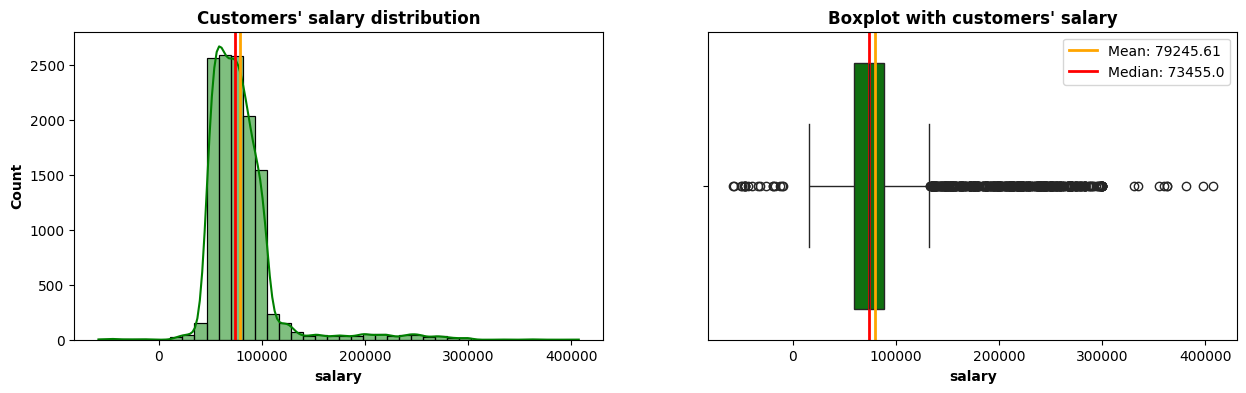

In [334]:
# LET'S VISUALIZE THE SALARY DISTRIBUTION TO UNDERSTAND MORE THE VALUES WE HAVE:
fig, axes = plt.subplots(ncols=2,nrows=1, figsize=(15,4)) 

sns.histplot(data=df_customers, x="salary",bins=40, ax=axes[0],color="green",kde=True); # histplot in position 0. 

sns.boxplot(data=df_customers, x="salary",ax=axes[1],color="green") # boxplot in position 1. 
axes[0].set_title("Customers' salary distribution")
axes[0].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[0].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[1].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[1].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[1].legend()
axes[1].set_title("Boxplot with customers' salary")
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold';

In [335]:
# Extended comments on salary distribution are in phase 2. However, here we can already see that most of the salaries are on the lower range.
# The histogram is right-skweded: The few very high salary values are influencing the whole salary column, therefore the mean is higher than the median.
# Some outliers are identified on the higher side and on the lower side (negative values).


In [336]:
# I create a mask to detect the negative salaries from the dataframe:
mask_negative_salary = df_customers["salary"] < 0
df_negative_salary = df_customers[mask_negative_salary]
print(f"We have {df_negative_salary.shape[0]} rows with negative salaries. Which accounts of {(round(df_negative_salary.shape[0]/df_customers.shape[0]*100,2))}% of all the salaries.")
display(df_negative_salary)
# The proportion of negative salaries is minimal, therefore I decide to change them to null values. 

We have 20 rows with negative salaries. Which accounts of 0.12% of all the salaries.


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
1082,158969,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,March,<NA>,NaN
1894,201683,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,March,<NA>,NaN
2471,233084,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,March,<NA>,NaN
3575,291831,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,March,<NA>,NaN
3932,311636,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,March,<NA>,NaN
4712,351897,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.0,Married,Star,7597.91,2018 Promotion,2018,March,<NA>,NaN
6560,450802,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,April,<NA>,NaN
6570,570806,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,March,<NA>,NaN
7373,492496,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,February,<NA>,NaN
8576,557723,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,February,<NA>,NaN


In [337]:
# I set the negative values as null:
df_customers.loc[mask_negative_salary, 'salary'] = np.nan 
print(f"Negative salaries left in df_customers: {(df_customers['salary']<0).sum()}")

Negative salaries left in df_customers: 0


In [338]:
# To verify the values are now all nulls:
df_negative_salary = df_customers[mask_negative_salary]
df_negative_salary["salary"].unique()

array([nan])

## 3. New columns added

### Active_customer (new column)

In [339]:
# I create a new column for active customers which will be used in the next phases:
df_customers["active_customer"] = df_customers["cancellation_year"].isnull() | df_customers["cancellation_month"].isnull()
df_customers["active_customer"].unique() 
# We have True whenever the cancellation year or month was null. We have False when the cancellation has taken place. 

array([ True, False])

In [340]:
df_customers.head(5) # To double check

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True
2,100140,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,July,2018,January,False
3,100214,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,February,<NA>,NaN,True
4,100272,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,October,<NA>,NaN,True


### Salary_category (new column)

In [341]:
# I want to create a new column to be able to classify the salaries between "normal" and "high_outliers". 
# This may be useful to be able to filter those customers with a high spending power for any potential marketing campagins.
# Prior to do that, I need to calculate the salary outliers:
IQR_salary = df_customers["salary"].quantile(0.75) - df_customers["salary"].quantile(0.25)

salary_inferior_limit = df_customers["salary"].quantile(0.25) - 1.5 * IQR_salary
salary_superior_limit = df_customers["salary"].quantile(0.75) + 1.5 * IQR_salary

superior_mask_salary = df_customers["salary"] > salary_superior_limit
inferior_mask_salary = df_customers["salary"] < salary_inferior_limit

outliers_filter_salary = df_customers[inferior_mask_salary | superior_mask_salary]

outliers_filter_salary["salary"].describe()

count       529.000000
mean     212940.735350
std       49343.706339
min      133080.000000
25%      172891.000000
50%      210090.000000
75%      250152.000000
max      407228.000000
Name: salary, dtype: float64

In [342]:
# Whenever the salary is higher than the superior limit, I set it up as "high_outlier", when is lower than the superior value: "normal".
df_customers["salary_category"] = np.where(df_customers["salary"] > salary_superior_limit,"high_outliers","normal")
print(f"""The new column salary_category has two values: 
      {df_customers['salary_category'].value_counts()}""")
display(df_customers.sample(5))

The new column salary_category has two values: 
      salary_category
normal           16208
high_outliers      529
Name: count, dtype: int64


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category
2786,250280,Canada,Quebec,Montreal,H2T 9K8,Male,Bachelor,71057.0,Single,Aurora,8873.53,Standard,2013,October,2018,January,False,normal
13449,815603,Canada,Manitoba,Winnipeg,R2C 0M5,Male,Bachelor,48780.0,Married,Star,5192.36,Standard,2012,July,<NA>,NaN,True,normal
15484,924489,Canada,Nova Scotia,Halifax,B3J 9S2,Male,College,NaN,Married,Star,9472.96,Standard,2012,September,<NA>,NaN,True,normal
12913,784946,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,Bachelor,90071.0,Divorced,Star,4626.80,Standard,2017,November,<NA>,NaN,True,normal
6366,440595,Canada,Quebec,Montreal,H2T 2J6,Female,College,NaN,Single,Nova,5075.42,Standard,2018,July,<NA>,NaN,True,normal


In [343]:
df_customers["salary_category"].unique() # To double check there are no nulls.

<StringArray>
['normal', 'high_outliers']
Length: 2, dtype: str

In [344]:
df_high_salaries = df_customers[df_customers["salary_category"] == "high_outliers"]
print(f"The new dataframe with only high salaries has: {df_high_salaries.shape[0]} rows.")
print(f"The mean salary from the df_high_salaries is: {round(df_high_salaries['salary'].mean(),2)}")
print(f"The median salary from the df_high_salaries is: {round(df_high_salaries['salary'].median(),2)}")
display(df_high_salaries.head(3))
# Both, mean and median are closer to each other.

The new dataframe with only high salaries has: 529 rows.
The mean salary from the df_high_salaries is: 212940.74
The median salary from the df_high_salaries is: 210090.0


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category
55,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,<NA>,NaN,True,high_outliers
60,103043,Canada,Nova Scotia,Halifax,B3J 9S2,Male,Doctor,152955.0,Married,Star,3954.34,Standard,2013,June,<NA>,NaN,True,high_outliers
61,103151,Canada,British Columbia,Vancouver,V6E 3Z3,Male,Doctor,152955.0,Married,Star,3954.34,Standard,2015,September,<NA>,NaN,True,high_outliers


## 4. Duplicated values 

### Duplicated rows:

In [345]:
# How many duplicated values do we have in each data frame?
print(f"Duplicated values in df_flights: {df_flights.duplicated().sum()}")
print(f"Duplicated values in df_customers: {df_customers.duplicated().sum()}")


Duplicated values in df_flights: 1864
Duplicated values in df_customers: 0


In [346]:
# I CREATE A MASK WITH THE CONDITION TO DISPLAY TRUE WHENEVER THE WHOLE ROW IS DUPLICATED:
mask_duplicated_flights = df_flights.duplicated()
mask_duplicated_flights

0         False
1         False
2         False
3         False
4         False
          ...  
405619    False
405620    False
405621    False
405622    False
405623    False
Length: 405624, dtype: bool

In [347]:
# TO GET A DATAFRAME WITH THE DUPLICATED VALUES I APPLY THE MASK TO THE DF_FLIGHTS (keep=False: to see both, the original and the copy)
mask_duplicated_flights = df_flights.duplicated(keep=False) 
df_flights[mask_duplicated_flights].sort_values(by="loyalty_number")
# As expected, we can see some duplicated rows (e.g. Customer 101902 has two exact rows for 2017 - December)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
41,101902,2017,January,0,0,0,0,0.0,0,0
33843,101902,2017,March,0,0,0,0,0.0,0,0
16942,101902,2017,February,0,0,0,0,0.0,0,0
185952,101902,2017,December,0,0,0,0,0.0,0,0
185953,101902,2017,December,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
354784,992168,2018,September,0,0,0,0,0.0,0,0
33665,992168,2017,February,0,0,0,0,0.0,0,0
33664,992168,2017,February,0,0,0,0,0.0,0,0
101269,992168,2017,June,0,0,0,0,0.0,0,0


In [348]:
# Number of rows before dropping the duplicated values:
print(f"Number of total rows before dropping the duplicated values: {df_flights.shape[0]} rows in total.")

Number of total rows before dropping the duplicated values: 405624 rows in total.


In [349]:
# To drop the duplicated values:
df_flights = df_flights.drop_duplicates()
print(f"Number of duplicated values on the flights dataframe: {df_flights.duplicated().sum()}")
print(f"Number of rows after dropping the duplicated values: {df_flights.shape[0]} rows in total.")


Number of duplicated values on the flights dataframe: 0
Number of rows after dropping the duplicated values: 403760 rows in total.


### Duplicated customers:

In [350]:
# I want to check if a customer appears more than once in the df_customers (perhaps with different province, city etc)
print(f"Duplicate customers: {df_customers.duplicated(subset=['loyalty_number']).sum()}")

Duplicate customers: 1959


In [351]:
# I am keeping the last entry (most likely the most updated one)
df_customers = df_customers.drop_duplicates(subset=['loyalty_number'], keep='last') 
print(f"Duplicated customers after droping: {df_customers.duplicated(subset=['loyalty_number']).sum()}")

Duplicated customers after droping: 0


In [352]:
df_flights.sort_values(by="loyalty_number")
#There are some customers that have no flights on specific months.

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,January,3,0,3,1521,152.0,0,0
46353,100018,2018,October,6,4,10,3110,311.0,385,31
321119,100018,2018,August,0,0,0,0,0.0,0,0
270416,100018,2018,May,0,0,0,0,0.0,0,0
50703,100018,2017,April,4,0,4,924,92.0,0,0
...,...,...,...,...,...,...,...,...,...,...
16900,999986,2017,January,1,0,1,1849,184.0,0,0
140741,999986,2018,August,8,1,9,3672,367.0,655,53
135207,999986,2017,August,12,0,12,1716,171.0,0,0
33801,999986,2017,February,7,0,7,3017,301.0,0,0


In [353]:
# I decide to create a mask to filter the dataframe where the flights booked is > 0. 
# This will be used in phase 2 to analyze the distance and points accumulated for example.
mask_flights_booked_exist = df_flights["flights_booked"] > 0
df_flights_booked = df_flights[mask_flights_booked_exist] # I create a new data frame.
df_flights_booked.head(5)


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,January,3,0,3,1521,152.0,0,0
1,100102,2017,January,10,4,14,2030,203.0,0,0
2,100140,2017,January,6,0,6,1200,120.0,0,0
8,100428,2017,January,6,0,6,606,60.0,0,0
10,100550,2017,January,3,0,3,2037,203.0,0,0


## 5. Null values imputation

In [354]:
# We only had nulls on the below columns from the customers dataframe:
df_nulls_customers 

,%_nulls
Cancellation Year,87.65
Cancellation Month,87.65
Salary,25.32


### Column "Salary"

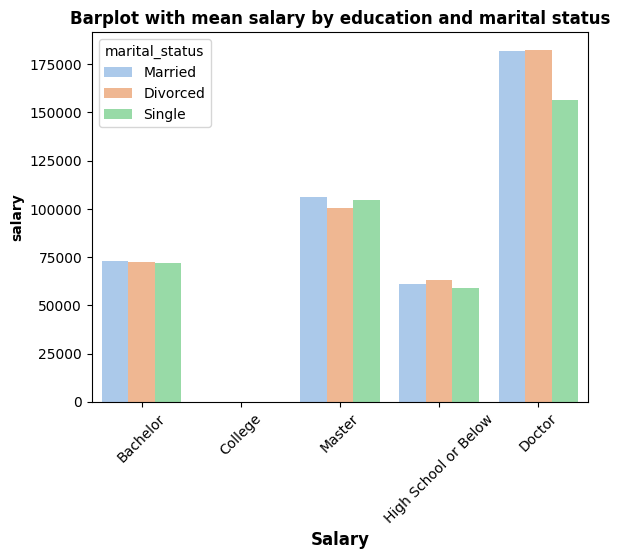

In [355]:

sns.barplot(data=df_customers, x="education", y="salary",errorbar=None, hue = "marital_status", palette="pastel")
plt.xticks(rotation=45)
plt.xlabel('Education', fontsize=12)
plt.xlabel('Salary', fontsize=12)
plt.title("Barplot with mean salary by education and marital status")
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold';
# Rx params: To have all titles and labels in bold
# I wanted to have a better overview of the salary distribution before taking any action. 
# I can see that we have no salary values for education level "college" (null values). Therefore I decide to imput the null values.

In [356]:
# I can verify that the top education category where the salary is null is college. 
# It makes sense: students have most likely no salary at all.
null_salaries = df_customers["salary"].isnull()
df_null_salaries = df_customers[null_salaries]
df_null_salaries.describe(include="str").T 


,count,unique,top,freq
country,3751,1,Canada,3751
province,3751,11,Ontario,1226
city,3751,29,Toronto,746
postal_code,3751,55,V6E 3D9,205
gender,3751,2,Male,1914
education,3751,3,College,3732
marital_status,3751,3,Single,2137
loyalty_card,3751,3,Star,1909
enrollment_type,3751,2,Standard,3516
salary_category,3751,1,normal,3751


**Imputation technique:**

High percentage of null salaries (>25%), therefore we cannot imput with the meadian. The mean was already discarded since we have some outliers and the mean and median values differ.

I decide to compare both: the **Iterative Imputer** and the **KNN** and compare the values. 

In [357]:
df_customers["education"].value_counts()

education
Bachelor                9244
College                 3732
High School or Below     696
Doctor                   653
Master                   453
Name: count, dtype: int64

In [358]:
education_map = {
    'High School or Below': 1,
    'College': 2,
    'Bachelor': 3,
    'Master': 4,
    'Doctor': 5
}
df_customers['education_level'] = df_customers['education'].map(education_map)
df_customers.head(3)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,education_level
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True,normal,3
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True,normal,2
2,100140,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,July,2018,January,False,normal,2


KNN:

In [359]:
df_customers.dtypes

loyalty_number         object
country                   str
province                  str
city                      str
postal_code               str
gender                    str
education                 str
salary                float64
marital_status            str
loyalty_card              str
clv                   float64
enrollment_type           str
enrollment_year         int64
enrollment_month       object
cancellation_year       Int64
cancellation_month     object
active_customer          bool
salary_category           str
education_level         int64
dtype: object

In [360]:
knn_imputer = KNNImputer(n_neighbors=5)

columns_knn = knn_imputer.fit_transform(df_customers[['salary','education_level']])

# creamos dos columnas nuevas con la imputacion con knn e iterative y nos quedamos con la que menos afecte
df_customers["salary_knn"] = columns_knn[:, 0] # we want only the first column
df_customers.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,education_level,salary_knn
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True,normal,3,83236.0
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True,normal,2,87237.4


Iterative imputer:

In [361]:
iterative_imputer = IterativeImputer(random_state=42,max_iter=20)
# Different rounds and will take the values that produces less alteration 
columns_iterative = iterative_imputer.fit_transform(df_customers[['salary','education_level']])
df_customers["salary_iterative"] = columns_iterative[:, 0]

df_customers.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,education_level,salary_knn,salary_iterative
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True,normal,3,83236.0,83236.000000
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True,normal,2,87237.4,49916.947778


In [362]:
df_customers.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'salary', 'marital_status', 'loyalty_card',
       'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month', 'active_customer',
       'salary_category', 'education_level', 'salary_knn', 'salary_iterative'],
      dtype='str')

In [363]:
df_customers[["salary","salary_knn","salary_iterative"]].agg(["mean","median"]).T


,mean,median
salary,79451.765213,73398.0
salary_knn,81429.602937,83267.0
salary_iterative,71988.017349,63654.0


After looking at the mean and median by each imputation techniques, I decide to choose the Iterative Imputer values since the KNN is overestimating the salaries (higher meadian). The reason behind may be the fact that the KNN looks at neighbours and if those have higher salaries, it influence the values. 

With the Iterative imputer, it focuses more on the relationship between other variables (like education). 

In [364]:
df_customers.drop(columns=["salary","salary_knn"], inplace=True)
df_customers.head(5)

,loyalty_number,country,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,education_level,salary_iterative
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True,normal,3,83236.000000
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True,normal,2,49916.947778
2,100140,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,Single,Star,3839.75,Standard,2014,July,2018,January,False,normal,2,49916.947778
3,100214,Canada,Ontario,Toronto,P1W 1K4,Male,College,Single,Star,3839.75,Standard,2013,February,<NA>,NaN,True,normal,2,49916.947778
4,100272,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,Married,Star,3842.79,Standard,2014,October,<NA>,NaN,True,normal,3,103495.000000


In [365]:
df_customers["salary"] = round(df_customers["salary_iterative"],2)
df_customers.drop(columns="salary_iterative",inplace=True)
df_customers.head(3)

,loyalty_number,country,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,education_level,salary
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True,normal,3,83236.00
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True,normal,2,49916.95
2,100140,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,Single,Star,3839.75,Standard,2014,July,2018,January,False,normal,2,49916.95


### Columns "cancellation_month" and "cancellation_year"

In [366]:
# I decide to drop these two columns and save the data in a new dataframe in case I need it:
columns_to_drop = ["cancellation_year", "cancellation_month"]
df_customers_with_cancellation = df_customers.copy()
df_customers = df_customers.drop(columns=columns_to_drop)

In [367]:
df_customers.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'marital_status', 'loyalty_card', 'clv',
       'enrollment_type', 'enrollment_year', 'enrollment_month',
       'active_customer', 'salary_category', 'education_level', 'salary'],
      dtype='str')

In [368]:
df_customers_with_cancellation.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,education_level,salary
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,<NA>,NaN,True,normal,3,83236.00
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,Divorced,Star,3839.61,Standard,2016,March,<NA>,NaN,True,normal,2,49916.95


In [369]:
df_customers.head(2) #To check that we have deleted both cancellation columns.

,loyalty_number,country,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,active_customer,salary_category,education_level,salary
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,True,normal,3,83236.00
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,Divorced,Star,3839.61,Standard,2016,March,True,normal,2,49916.95


# 3. Dataframes unification

In [370]:
set(df_flights["loyalty_number"].unique()) == set(df_customers["loyalty_number"].unique())

False

In [371]:
# We extract the unique loyalty numbers from both dataframes into sets:
set_flights = set(df_flights["loyalty_number"])
set_customers = set(df_customers["loyalty_number"])
# We identify any mismatch, regardless of which dataframe it is in:
missing_customers = set_flights.symmetric_difference(set_customers)
print(f"There are {len(missing_customers)} customers that don't have a match")
# We look for the IDs that exist in flights but are missing on the customer dataframe:
only_in_flights = set_flights-set_customers
# We look for the IDs that exist in customers but are missing on the flights dataframe:
only_in_customers = set_customers-set_flights
print(f"Customers missing from the Customers df: {len(only_in_flights)}") # There are some customers in df_flight that are missing in the df_customers
print(f"Customers missing from the Flights df: {len(only_in_customers)}") # Every customer in the df_customers flew at least one. 


There are 1959 customers that don't have a match
Customers missing from the Customers df: 1959
Customers missing from the Flights df: 0


I decide to join the dataframes with a **left join**. Being the df_customers on the left and the df_flights on the right.

By doing that I make sure that I analyze flight data of customers that we actually have records on. 

In [372]:
# I decide to join the dataframes with a left join. Being the df_customers on the left and the df_flights on the right
# By doing that I make sure that I analyze flight data of customers that we actually have records on. 

In [373]:
df_master = df_customers.merge(df_flights, on = "loyalty_number", how="left")
display(df_master.head(3))
print(df_master.shape)

,loyalty_number,country,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,active_customer,salary_category,education_level,salary,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,True,normal,3,83236.0,2017,January,3,0,3,1521,152.0,0,0
1,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,True,normal,3,83236.0,2017,February,2,2,4,1320,132.0,0,0
2,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,February,True,normal,3,83236.0,2018,October,6,4,10,3110,311.0,385,31


(356685, 26)


In [374]:
df_merged_high_salaries = df_high_salaries.merge(df_flights, on= "loyalty_number", how="left")
display(df_merged_high_salaries.head(3))
print(df_merged_high_salaries.shape)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,<NA>,NaN,True,high_outliers,2017,January,0,0,0,0,0.0,0,0
1,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,<NA>,NaN,True,high_outliers,2017,February,0,0,0,0,0.0,0,0
2,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,<NA>,NaN,True,high_outliers,2017,March,0,0,0,0,0.0,0,0


(12779, 27)


In [375]:
df_customers.to_csv("clean-data/customer-loyal-history-clean.csv",index=False)
df_flights.to_csv("clean-data/customer-flight-activity-clean.csv",index=False)
df_master.to_csv("clean-data/merged-master-data-clean.csv",index=False)
df_merged_high_salaries.to_csv("clean-data/merged-high-salaries-clean.csv", index=False)
df_flights_booked.to_csv("clean-data/flights-booked-not-zero.csv",index=False)